# Action-Angle Coordinates: Orbit Integration-based (IsochroneApprox)

The `actionAngleIsochroneApprox` method ([Bovy 2014](http://adsabs.harvard.edu/abs/2014ApJ...795...95B))
computes actions by integrating the orbit. By employing an auxiliary isochrone potential, ``actionAngleIsochroneApprox`` calculates action-angle variables by arithmetic operations on the actions and angles calculated in the auxiliary potential along an orbit (integrated in the true potential). Full details can be found in Appendix A of Bovy (2014). This method is completely
general for any static potential and can calculate actions to any desired
precision for any orbit, including orbits in triaxial potentials.

The [adiabatic](adiabatic.ipynb) and [Staeckel](staeckel.ipynb) approximations are good for stars on
close-to-circular orbits, but they break down for more eccentric orbits
(specifically, orbits for which the radial and/or vertical action is of
a similar magnitude as the angular momentum). The `actionAngleIsochroneApprox`
method overcomes this limitation.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import LogarithmicHaloPotential
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Setup

We set up the method for a flattened logarithmic potential. The key parameter
is `b`, the scale parameter of the auxiliary isochrone potential (this can
also be specified as an `IsochronePotential` instance through `ip=`):

In [2]:
from galpy.actionAngle import actionAngleIsochroneApprox

lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
aAIA = actionAngleIsochroneApprox(pot=lp, b=0.8)

## Estimating the optimal b parameter

The `estimateBIsochrone` function estimates a good scale parameter for the
auxiliary isochrone potential. When given multiple $R$ and $z$ values (e.g.,
from an orbit), it returns the minimum, median, and maximum $b$:

In [3]:
from galpy.actionAngle import estimateBIsochrone

# An orbit similar to GD-1
obs = numpy.array(
    [1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596]
)

o = Orbit(obs)
ts = numpy.linspace(0.0, 100.0, 1001)
o.integrate(ts, lp)

bmin, bmed, bmax = estimateBIsochrone(lp, o.R(ts), o.z(ts))
print(f"b_min = {bmin:.4f}, b_median = {bmed:.4f}, b_max = {bmax:.4f}")

b_min = 0.7807, b_median = 1.2266, b_max = 1.4899


Experience shows that a scale parameter somewhere in this range makes sure
that the angles go through the full $[0, 2\pi]$ range, which is required for the method. If they do not,
galpy will raise a warning.

## Computing actions

Note that `actionAngleIsochroneApprox` returns arrays even for single inputs:

In [4]:
jr, jphi, jz = aAIA(*obs)
print(f"J_R = {jr[0]:.6f}, L_z = {jphi[0]:.6f}, J_z = {jz[0]:.6f}")

J_R = 0.166050, L_z = -1.803222, J_z = 0.507044


## Convergence: the importance of choosing a good b

An essential requirement is that the angles calculated in the auxiliary
potential go through the full range $[0, 2\pi]$. If this is not the case,
galpy will raise a warning and the actions will not be reliable.

Let's see what happens with a poor choice of `b`:

In [5]:
import warnings

aAIA_bad = actionAngleIsochroneApprox(pot=lp, b=1.5)
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    jr_bad, _, jz_bad = aAIA_bad(*obs)
    if w:
        print(f"Warning: {w[0].message}")
print(f"J_R (b=1.5) = {jr_bad[0]:.6f} vs J_R (b=0.8) = {jr[0]:.6f}")

J_R (b=1.5) = 0.011201 vs J_R (b=0.8) = 0.166050


## The plot() method: inspecting convergence

We can inspect how the angles increase and how the actions converge using
the `aAIA.plot` function.

First, let's look at the poor `b=1.5` case. The radial vs. vertical angle
in the auxiliary potential shows very non-linear behavior:

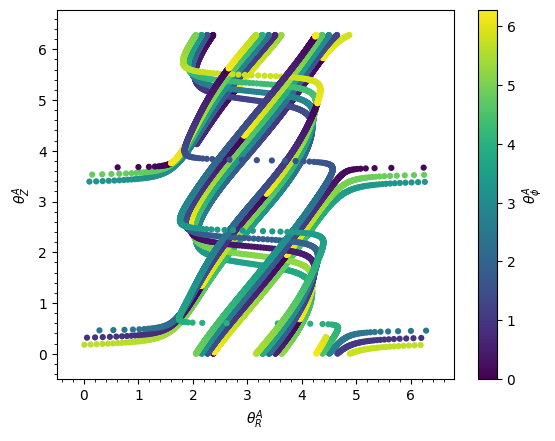

In [6]:
aAIA_bad.plot(*obs, type="araz");

The convergence of $J_R$ is also very slow:

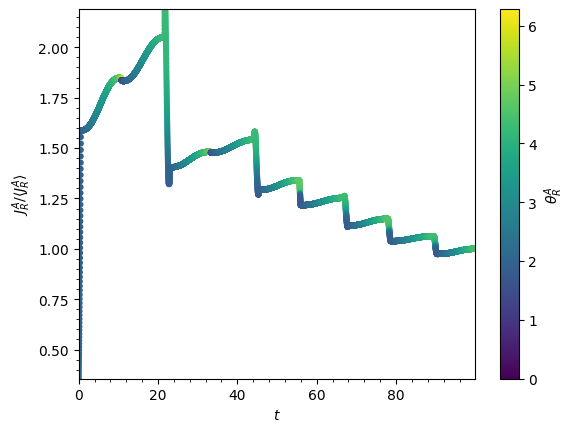

In [7]:
aAIA_bad.plot(*obs, type="jr");

Now compare with the good `b=0.8` choice, which shows quick convergence:

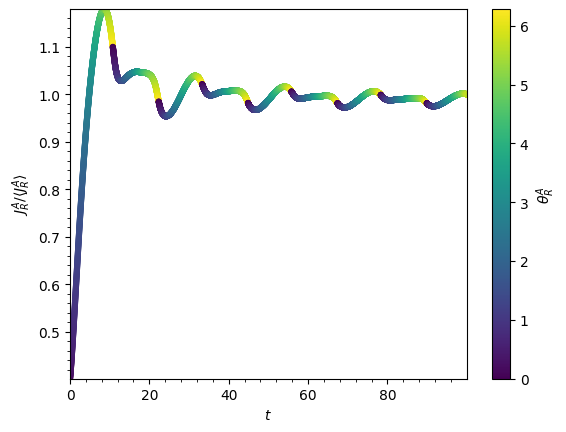

In [8]:
aAIA.plot(*obs, type="jr");

The angle-angle plot with `b=0.8` shows much more linear behavior:

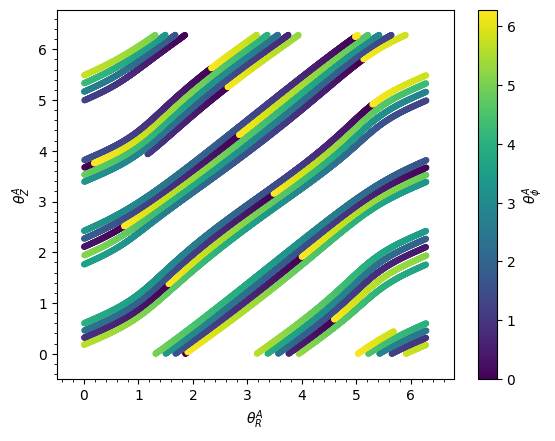

In [9]:
aAIA.plot(*obs, type="araz");

## Deperioding the angles

We can remove the periodic behavior from the angles using `deperiod=True`,
which clearly shows that they increase close-to-linearly with time:

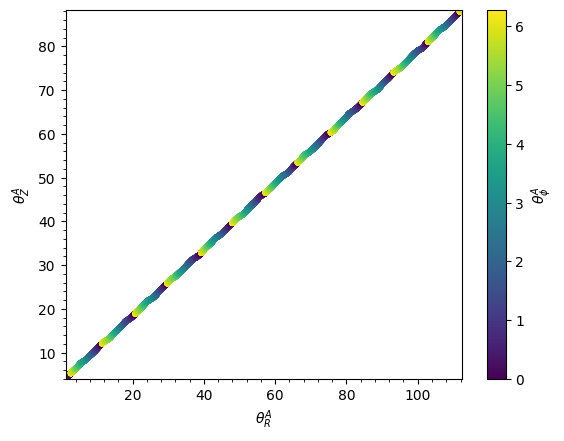

In [10]:
aAIA.plot(*obs, type="araz", deperiod=True);

## Computing frequencies and angles

With a good auxiliary potential, we can also compute frequencies and angles.
The `maxn` argument controls the maximum $n$ for which sinusoidal wiggles
are removed:

In [11]:
result = aAIA.actionsFreqsAngles(*obs)
print(f"J_R = {result[0][0]:.6f}, L_z = {result[1][0]:.6f}, J_z = {result[2][0]:.6f}")
print(
    f"Omega_R = {result[3][0]:.6f}, Omega_phi = {result[4][0]:.6f}, Omega_z = {result[5][0]:.6f}"
)
print(
    f"theta_R = {result[6][0]:.6f}, theta_phi = {result[7][0]:.6f}, theta_z = {result[8][0]:.6f}"
)

J_R = 0.163924, L_z = -1.803222, J_z = 0.509999
Omega_R = 0.558089, Omega_phi = -0.384758, Omega_z = 0.421997
theta_R = 0.187397, theta_phi = 0.313182, theta_z = 2.184257


Raising `maxn` from 3 (default) to 4 shows little change, confirming convergence:

In [12]:
# Raising maxn from 3 (default) to 4 shows little change, confirming convergence
result4 = aAIA.actionsFreqsAngles(*obs, maxn=4)
print(f"J_R (maxn=3) = {result[0][0]:.6f}, J_R (maxn=4) = {result4[0][0]:.6f}")
print(f"Omega_R (maxn=3) = {result[3][0]:.6f}, Omega_R (maxn=4) = {result4[3][0]:.6f}")

J_R (maxn=3) = 0.163924, J_R (maxn=4) = 0.163924
Omega_R (maxn=3) = 0.558089, Omega_R (maxn=4) = 0.558088


## Triaxial potentials

This technique also works for triaxial potentials by specifying `nonaxi=True`.
This tells the code to also use the azimuthal angle variable in the
auxiliary potential (unnecessary in axisymmetric potentials where $L_z$ is
conserved):

In [13]:
from galpy.potential import TriaxialNFWPotential

# A MW-like triaxial halo setup (roughly NFW scale radius a~2 in galpy units)
tp = TriaxialNFWPotential(normalize=1.0, a=2.0, b=0.95, c=0.85)
aAIA_triax = actionAngleIsochroneApprox(pot=tp, b=0.8)

jr_nonaxi, jphi_nonaxi, jz_nonaxi = aAIA_triax(*obs, nonaxi=True)

print(f"Triaxial J_R (nonaxi=True) = {jr_nonaxi[0]:.6f}")
print(f"Triaxial J_phi (nonaxi=True) = {jphi_nonaxi[0]:.6f}")
print(f"Triaxial J_z (nonaxi=True) = {jz_nonaxi[0]:.6f}")

Triaxial J_R (nonaxi=True) = 0.030449
Triaxial J_phi (nonaxi=True) = -1.781219
Triaxial J_z (nonaxi=True) = 0.531130


## Comparison with other methods

For a standard potential like `MWPotential2014`, we can compare all three
forward methods:

In [14]:
from galpy.potential import MWPotential2014
from galpy.actionAngle import actionAngleStaeckel, actionAngleAdiabatic

aAS = actionAngleStaeckel(pot=MWPotential2014, delta=0.4, c=True)
aAA = actionAngleAdiabatic(pot=MWPotential2014, c=True)
aAIA_mw = actionAngleIsochroneApprox(pot=MWPotential2014, b=0.8)

R, vR, vT, z, vz, phi = 1.0, 0.1, 1.1, 0.0, 0.05, 0.0

jr_st, _, jz_st = aAS(R, vR, vT, z, vz)
jr_ad, _, jz_ad = aAA(R, vR, vT, z, vz)
jr_ia, _, jz_ia = aAIA_mw(R, vR, vT, z, vz, phi)

print("Method            J_R        J_z")
print(f"Staeckel:         {jr_st.item():.6f}   {jz_st.item():.6f}")
print(f"Adiabatic:        {jr_ad.item():.6f}   {jz_ad.item():.6f}")
print(f"IsochroneApprox:  {jr_ia[0]:.6f}   {jz_ia[0]:.6f}")

Method            J_R        J_z
Staeckel:         0.013636   0.000463
Adiabatic:        0.013525   0.000469
IsochroneApprox:  0.013629   0.000466
